# Per-Pulse Outlier Analysis
Scan the `per_pulse/` output folder for all `ro_*_merged.h5` files.  
For each pulse shape:
1. Run `SingleStateOutlierAnalyzer` on the reference channel (`I1_1`/`Q1_1`) to get the Gaussian fit.  
2. Re-run with fixed parameters on the measurement channels (`_2`, `_3`).  
3. Collect outlier probabilities across pulse shapes and plot them.

In [21]:
import os
import glob
import re

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.protocols.single_state_outlier import SingleStateOutlierAnalyzer

## 1. Configuration

In [22]:
# Path to the per_pulse folder produced by 1_pulse_shape_stable_merge.ipynb
PULSE_DIR = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse"

# Outlier detection threshold (number of sigma)
OUTLIER_SIGMA = 3

# Mapping from pulse name to an integer index for the x-axis
# Adjust ordering / numbering as needed
PULSE_ORDER = {
    "readout_square": 4000,
    "readout_three_step": 100,
    "readout_three_step_120": 120,
    "readout_three_step_140": 140,
    "readout_three_step_160": 160,
    "readout_three_step_200": 200,
    "readout_three_step_240": 240,
    "readout_three_step_300": 300,
    "readout_three_step_340": 340,
    "readout_three_step_400": 400,
    "readout_three_step_500": 500,
    "readout_three_step_600": 600,
    "readout_three_step_800": 800,
    "readout_three_step_1000": 1000,
    "readout_three_step_1200": 1200,

}

# Output
FIGURE_SAVE_PATH = os.path.join(os.path.dirname(PULSE_DIR), "figures", "per_pulse_outlier")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

## 2. Discover Merged Files

In [23]:
pattern = os.path.join(PULSE_DIR, "ro_*_merged.h5")
h5_files = sorted(glob.glob(pattern))

# Extract pulse name from filename: ro_{pulse_name}_merged.h5
pulse_files = {}
for f in h5_files:
    basename = os.path.basename(f)
    m = re.match(r"ro_(.+)_merged\.h5$", basename)
    if m:
        pulse_files[m.group(1)] = f

print(f"Found {len(pulse_files)} merged pulse files:")
for name, path in pulse_files.items():
    print(f"  {name:40s}  {path}")

Found 5 merged pulse files:
  readout_square                            D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\ro_readout_square_merged.h5
  readout_three_step_1000                   D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\ro_readout_three_step_1000_merged.h5
  readout_three_step_200                    D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\ro_readout_three_step_200_merged.h5
  readout_three_step_400                    D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\ro_readout_three_step_400_merged.h5
  readout_three_step                        D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\ro_readout_three_ste

## 3. Reference Fit (I1_1/Q1_1) per Pulse
Flatten all dims into `shot_idx` and run `SingleStateOutlierAnalyzer` to get the Gaussian center & std.

In [24]:
analyzer = SingleStateOutlierAnalyzer()

ref_results = {}   # pulse_name -> (results_dict, dataset)

for pulse_name, h5_path in pulse_files.items():
    print(f"\n--- {pulse_name} ---")
    ds = load_xarray_h5(h5_path)

    # Flatten all dims into a single shot_idx
    all_dims = list(ds["I1_1"].dims)
    I_flat = ds["I1_1"].values.ravel()
    Q_flat = ds["Q1_1"].values.ravel()
    ds_ref = xr.Dataset(
        {"I": ("shot_idx", I_flat), "Q": ("shot_idx", Q_flat)},
        coords={"shot_idx": np.arange(len(I_flat))},
    )

    results, figs = analyzer.analyze(ds_ref, outlier_sigma=OUTLIER_SIGMA)

    mean = results["fitted_paras"]["mean"][0]
    std = results["fitted_paras"]["std"]
    print(f"  mean=[{mean[0]:.4f}, {mean[1]:.4f}]  std={std:.4f}")
    print(f"  ref outlier_probability={results['outlier_probability']:.4f}  "
          f"  n_shots={len(I_flat)}")

    for fig_name, fig in figs.items():
        fig.suptitle(f"{pulse_name} | ref (I1_1/Q1_1) | {fig_name}", fontsize=12, y=1.02)
        fig.savefig(
            os.path.join(FIGURE_SAVE_PATH, f"{pulse_name}_ref_{fig_name}.png"),
            dpi=150, bbox_inches="tight",
        )
        plt.show()
        plt.close(fig)

    ref_results[pulse_name] = (results, ds)


--- readout_square ---
  mean=[-0.0022, -0.0013]  std=0.0006
  ref outlier_probability=0.0147    n_shots=64000

--- readout_three_step_1000 ---
  mean=[-0.0023, -0.0013]  std=0.0006
  ref outlier_probability=0.0177    n_shots=72000

--- readout_three_step_200 ---
  mean=[-0.0022, -0.0013]  std=0.0006
  ref outlier_probability=0.0255    n_shots=68000

--- readout_three_step_400 ---
  mean=[-0.0022, -0.0013]  std=0.0006
  ref outlier_probability=0.0178    n_shots=84000

--- readout_three_step ---
  mean=[-0.0022, -0.0014]  std=0.0006
  ref outlier_probability=0.0180    n_shots=84000


## 4. Outlier Detection on _2 and _3 Channels (Fixed Fit)
Use the reference Gaussian parameters from step 3 to detect outliers in `I1_2/Q1_2` and `I1_3/Q1_3`.

In [25]:
# === Pass 1: Free-fit set_2 to collect per-pulse std ===
set2_free_stds = {}
set2_free_means = {}

for pulse_name, (ref_res, ds) in ref_results.items():
    ref_mask = ref_res["outlier_mask"]
    I_flat = ds["I1_2"].values.ravel()
    Q_flat = ds["Q1_2"].values.ravel()

    keep = ~ref_mask
    I_clean = I_flat[keep]
    Q_clean = Q_flat[keep]

    ds_flat = xr.Dataset(
        {"I": ("shot_idx", I_clean), "Q": ("shot_idx", Q_clean)},
        coords={"shot_idx": np.arange(len(I_clean))},
    )
    res, _ = analyzer.analyze(ds_flat, outlier_sigma=OUTLIER_SIGMA)
    set2_free_stds[pulse_name] = float(res["fitted_paras"]["std"])
    set2_free_means[pulse_name] = res["fitted_paras"]["mean"][0]
    plt.close("all")

avg_set2_std = float(np.mean(list(set2_free_stds.values())))
print(f"Average set2_std = {avg_set2_std:.6f}")
for pn, s in set2_free_stds.items():
    print(f"  {pn:40s}  std={s:.6f}")

# === Pass 2: Main analysis using avg_set2_std as fixed std for set_2 ===
summary_records = []

for pulse_name, (ref_res, ds) in ref_results.items():
    fixed_mean = ref_res["fitted_paras"]["mean"][0]
    fixed_std = ref_res["fitted_paras"]["std"]
    ref_mask = ref_res["outlier_mask"]

    n_total = int(np.prod([ds.sizes[d] for d in ds["I1_1"].dims]))
    n_post = int((~ref_mask).sum())

    record = {
        "pulse_name": pulse_name,
        "n_shots": n_total,
        "n_shots_post": n_post,
        "ref_outlier": ref_res["outlier_probability"],
        "ref_mean_I": float(fixed_mean[0]),
        "ref_mean_Q": float(fixed_mean[1]),
        "ref_std": float(fixed_std),
    }

    for suffix, i_var, q_var in [("set2", "I1_2", "Q1_2"), ("set3", "I1_3", "Q1_3")]:
        I_flat = ds[i_var].values.ravel()
        Q_flat = ds[q_var].values.ravel()

        # Post-selection: remove shots that are outliers in the reference channel
        keep = ~ref_mask
        I_clean = I_flat[keep]
        Q_clean = Q_flat[keep]

        ds_flat = xr.Dataset(
            {"I": ("shot_idx", I_clean), "Q": ("shot_idx", Q_clean)},
            coords={"shot_idx": np.arange(len(I_clean))},
        )
        if suffix == "set2":
            # Fixed fit for set_2: own free-fit mean + average set2_std
            res, set_figs = analyzer.analyze(
                ds_flat,
                # fixed_mean=set2_free_means[pulse_name],
                fixed_std=avg_set2_std,
                outlier_sigma=OUTLIER_SIGMA,
            )
        else:
            # Fixed fit for set_3 using ref mean/std
            res, set_figs = analyzer.analyze(
                ds_flat,
                fixed_mean=fixed_mean, fixed_std=fixed_std,
                outlier_sigma=OUTLIER_SIGMA,
            )
        record[f"{suffix}_outlier"] = res["outlier_probability"]
        record[f"{suffix}_std"] = float(res["fitted_paras"]["std"])

        # Show and save fitting figures
        for fig_name, fig in set_figs.items():
            fig.suptitle(f"{pulse_name} | {suffix} ({i_var}/{q_var}) | {fig_name}", fontsize=12, y=1.02)
            fig.savefig(
                os.path.join(FIGURE_SAVE_PATH, f"{pulse_name}_{suffix}_{fig_name}.png"),
                dpi=150, bbox_inches="tight",
            )
            plt.show()
            plt.close(fig)

    summary_records.append(record)
    print(f"{pulse_name:40s}  n={record['n_shots']:6d}  n_post={record['n_shots_post']:6d}  "
          f"ref={record['ref_outlier']:.4f}  "
          f"set2={record['set2_outlier']:.4f}  "
          f"set3={record['set3_outlier']:.4f}")

Average set2_std = 0.000403
  readout_square                            std=0.000400
  readout_three_step_1000                   std=0.000404
  readout_three_step_200                    std=0.000406
  readout_three_step_400                    std=0.000405
  readout_three_step                        std=0.000399
readout_square                            n= 64000  n_post= 63060  ref=0.0147  set2=0.0515  set3=0.0359
readout_three_step_1000                   n= 72000  n_post= 70729  ref=0.0177  set2=0.0847  set3=0.0583
readout_three_step_200                    n= 68000  n_post= 66264  ref=0.0255  set2=0.0427  set3=0.0444
readout_three_step_400                    n= 84000  n_post= 82507  ref=0.0178  set2=0.0451  set3=0.0459
readout_three_step                        n= 84000  n_post= 82487  ref=0.0180  set2=0.0344  set3=0.0426


## 5. Summary Table

In [26]:
# Build an xarray Dataset indexed by pulse_name for easy access
pulse_names = [r["pulse_name"] for r in summary_records]
summary_ds = xr.Dataset(
    {
        "n_shots":       ("pulse", [r["n_shots"]       for r in summary_records]),
        "n_shots_post": ("pulse", [r["n_shots_post"]  for r in summary_records]),
        "ref_outlier":   ("pulse", [r["ref_outlier"]   for r in summary_records]),
        "set2_outlier":  ("pulse", [r["set2_outlier"]  for r in summary_records]),
        "set3_outlier":  ("pulse", [r["set3_outlier"]  for r in summary_records]),
        "ref_mean_I":    ("pulse", [r["ref_mean_I"]    for r in summary_records]),
        "ref_mean_Q":    ("pulse", [r["ref_mean_Q"]    for r in summary_records]),
        "ref_std":       ("pulse", [r["ref_std"]       for r in summary_records]),
        "set2_std":     ("pulse", [r["set2_std"]      for r in summary_records]),
        "set3_std":     ("pulse", [r["set3_std"]      for r in summary_records]),
    },
    coords={"pulse": pulse_names},
)
print(f"{'Pulse':40s}  {'n_shots':>7s}  {'n_post':>7s}  {'ref':>8s}  {'set2':>8s}  {'set3':>8s}")
print("-" * 85)
for r in summary_records:
    print(f"{r['pulse_name']:40s}  {r['n_shots']:7d}  {r['n_shots_post']:7d}  "
          f"{r['ref_outlier']:8.4f}  {r['set2_outlier']:8.4f}  {r['set3_outlier']:8.4f}")

Pulse                                     n_shots   n_post       ref      set2      set3
-------------------------------------------------------------------------------------
readout_square                              64000    63060    0.0147    0.0515    0.0359
readout_three_step_1000                     72000    70729    0.0177    0.0847    0.0583
readout_three_step_200                      68000    66264    0.0255    0.0427    0.0444
readout_three_step_400                      84000    82507    0.0178    0.0451    0.0459
readout_three_step                          84000    82487    0.0180    0.0344    0.0426


## 6. Outlier Probability vs Pulse Shape

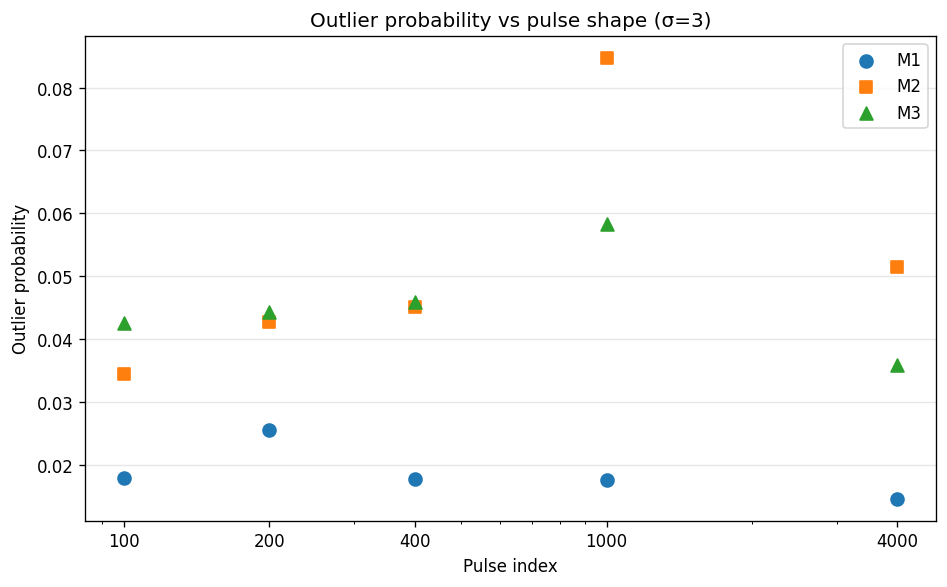

In [27]:
sorted_names = sorted(pulse_names, key=lambda n: PULSE_ORDER[n])
sorted_x = [PULSE_ORDER[n] for n in sorted_names]

# Reorder summary values
name_to_pos = {n: i for i, n in enumerate(pulse_names)}
sorted_ref  = [summary_ds["ref_outlier"].values[name_to_pos[n]]  for n in sorted_names]
sorted_set2 = [summary_ds["set2_outlier"].values[name_to_pos[n]] for n in sorted_names]
sorted_set3 = [summary_ds["set3_outlier"].values[name_to_pos[n]] for n in sorted_names]

x = np.array(sorted_x, dtype=float)

fig, ax = plt.subplots(figsize=(max(8, len(sorted_names) * 1.5), 5), dpi=120)
ax.scatter(x, sorted_ref,  marker="o", s=60, label="M1", color="C0", zorder=3)
ax.scatter(x, sorted_set2, marker="s", s=60, label="M2", color="C1", zorder=3)
ax.scatter(x, sorted_set3, marker="^", s=60, label="M3", color="C2", zorder=3)

ax.set_xscale("log")
ax.set_xticks(sorted_x)
ax.set_xticklabels([str(v) for v in sorted_x])
ax.set_xlabel("Pulse index")
ax.set_ylabel("Outlier probability")
ax.set_title(f"Outlier probability vs pulse shape (σ={OUTLIER_SIGMA})")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_SAVE_PATH, "outlier_vs_pulse.png"), dpi=150, bbox_inches="tight")
plt.show()

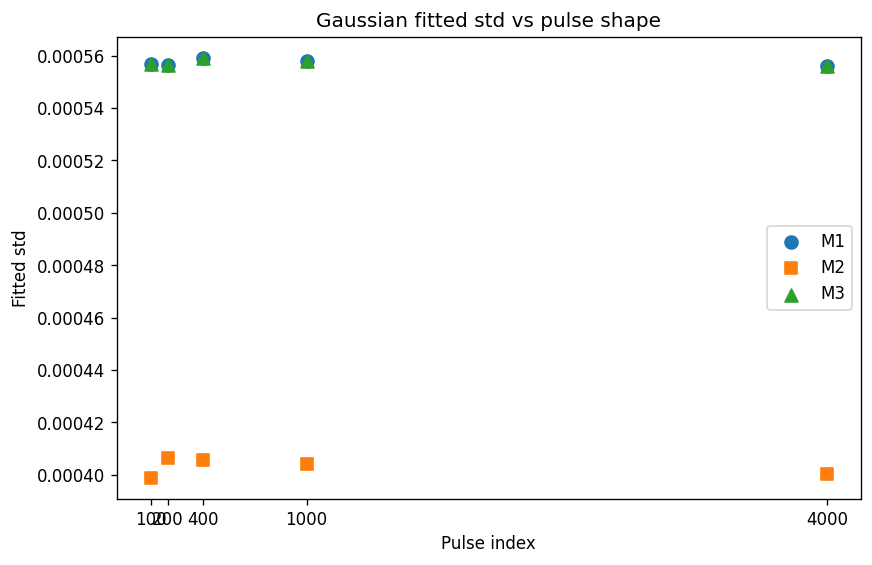

In [28]:
sorted_ref_std  = [summary_ds["ref_std"].values[name_to_pos[n]]  for n in sorted_names]
sorted_set2_std = [summary_ds["set2_std"].values[name_to_pos[n]] for n in sorted_names]
sorted_set3_std = [summary_ds["set3_std"].values[name_to_pos[n]] for n in sorted_names]

fig, ax = plt.subplots(figsize=(max(8, len(sorted_names) * 1.5), 5), dpi=120)
ax.scatter(x, sorted_ref_std,  marker="o", s=60, label="M1", color="C0", zorder=3)
ax.scatter(x, sorted_set2_std, marker="s", s=60, label="M2", color="C1", zorder=3)
ax.scatter(x, sorted_set3_std, marker="^", s=60, label="M3", color="C2", zorder=3)

ax.set_xticks(sorted_x)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Fitted std")
ax.set_title("Gaussian fitted std vs pulse shape")

ax.legend()
plt.show()

ax.grid(True, alpha=0.3, axis="y")
fig.savefig(os.path.join(FIGURE_SAVE_PATH, "std_vs_pulse.png"), dpi=150, bbox_inches="tight")
fig.tight_layout()

In [29]:
# Save summary dataset
out_path = os.path.join(PULSE_DIR, "outlier_summary.h5")
if os.path.exists(out_path):
    os.remove(out_path)
summary_ds.to_netcdf(out_path, engine="h5netcdf")
print(f"Saved summary to {out_path}")

Saved summary to D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\MWF\op_A13_ngv08_5T\per_pulse\outlier_summary.h5


In [30]:
for pulse_name, (_, ds) in ref_results.items():
    ps = ds.coords["prepared_state"].values if "prepared_state" in ds.coords else "N/A"
    cg = ds.coords["charge_gate"].values if "charge_gate" in ds.coords else "N/A"
    ap = ds.coords["amp_prefactor"].values if "amp_prefactor" in ds.coords else "N/A"
    print(f"--- {pulse_name} ---")
    print(f"  prepared_state : {ps}")
    print(f"  charge_gate    : {cg}")
    print(f"  amp_prefactor  : {ap}")
    print()

--- readout_square ---
  prepared_state : [0]
  charge_gate    : [0.08]
  amp_prefactor  : [1.3]

--- readout_three_step_1000 ---
  prepared_state : [0]
  charge_gate    : [0.08]
  amp_prefactor  : [1.3]

--- readout_three_step_200 ---
  prepared_state : [0]
  charge_gate    : [0.08]
  amp_prefactor  : [1.3]

--- readout_three_step_400 ---
  prepared_state : [0]
  charge_gate    : [0.08]
  amp_prefactor  : [1.3]

--- readout_three_step ---
  prepared_state : [0]
  charge_gate    : [0.08]
  amp_prefactor  : [1.3]

